# Validacion Avanzada, Tuning e Interpretabilidad

En este notebook aplicamos tecnicas avanzadas de validacion, optimizacion de hiperparametros e interpretabilidad de modelos.

---

## Objetivo

Realizar un analisis exhaustivo de los tres mejores modelos identificados en la etapa de evaluacion:

1. **XGBoost**
2. **Random Forest**
3. **Arbol de Decision**

---

## Metodologia

- **Tuning de Hiperparametros:** Uso de sklearn.Pipeline con GridSearchCV y BayesSearchCV
- **Validacion Cruzada:** StratifiedKFold con minimo 5 folds
- **Interpretabilidad:** Aplicacion de feature_importances_, SHAP y Permutation Importance

---

## Datos

Utilizamos los datos preprocesados de `../data/processed/`:
- Escalados con StandardScaler
- Codificados (One-Hot Encoding)
- Train balanceado con SMOTE
- Sin valores faltantes

## 1. Importar Librerias

In [1]:
# Librerias basicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
from pathlib import Path

# Modelos de clasificacion
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Pipeline y transformadores
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Validacion cruzada
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score, cross_validate
 )

# Busqueda de hiperparametros
from sklearn.model_selection import GridSearchCV
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
from optuna.integration import OptunaSearchCV
import optuna

# Metricas
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, make_scorer, classification_report
 )

# Interpretabilidad
from sklearn.inspection import permutation_importance
import shap

warnings.filterwarnings('ignore')

# Configuracion de visualizacion
plt.style.use('default')
sns.set_palette("pastel")
pd.set_option('display.max_columns', None)

print("Librerias importadas correctamente")

Librerias importadas correctamente


## 2. Cargar Datos Preprocesados

In [2]:
print("Cargando datos procesados de '../data/processed/'...\n")

# Cargar datos de entrenamiento (BALANCEADOS con SMOTE)
X_train = pd.read_csv('../data/processed/X_train.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').values.ravel()

# Cargar datos de validacion (SIN balancear)
X_val = pd.read_csv('../data/processed/X_val.csv')
y_val = pd.read_csv('../data/processed/y_val.csv').values.ravel()

# Cargar datos de test (SIN balancear)
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').values.ravel()

print("Datos cargados exitosamente\n")

# Informacion de los datos
print("="*60)
print(" "*15 + "INFORMACION DE LOS DATOS")
print("="*60)
print(f"\nDimensiones:")
print(f"  Train:      {X_train.shape[0]:>7,} muestras × {X_train.shape[1]:>3} features")
print(f"  Validation: {X_val.shape[0]:>7,} muestras × {X_val.shape[1]:>3} features")
print(f"  Test:       {X_test.shape[0]:>7,} muestras × {X_test.shape[1]:>3} features")

print(f"\nBalance de clases (Test - datos reales):")
test_counts = pd.Series(y_test).value_counts()
print(f"  Clase 0: {test_counts[0]:>7,} ({test_counts[0]/len(y_test)*100:>5.1f}%)")
print(f"  Clase 1: {test_counts[1]:>7,} ({test_counts[1]/len(y_test)*100:>5.1f}%)")

print("\n" + "="*60)

# Guardar nombres de features
feature_names = X_train.columns.tolist()
print(f"\nTotal de features: {len(feature_names)}")

Cargando datos procesados de '../data/processed/'...

Datos cargados exitosamente

               INFORMACION DE LOS DATOS

Dimensiones:
  Train:       71,236 muestras × 113 features
  Validation:  15,265 muestras × 113 features
  Test:        15,265 muestras × 113 features

Balance de clases (Test - datos reales):
  Clase 0:   8,230 ( 53.9%)
  Clase 1:   7,035 ( 46.1%)


Total de features: 113
Datos cargados exitosamente

               INFORMACION DE LOS DATOS

Dimensiones:
  Train:       71,236 muestras × 113 features
  Validation:  15,265 muestras × 113 features
  Test:        15,265 muestras × 113 features

Balance de clases (Test - datos reales):
  Clase 0:   8,230 ( 53.9%)
  Clase 1:   7,035 ( 46.1%)


Total de features: 113


In [3]:
# Convertir DataFrames a NumPy arrays para evitar problemas con nombres de columnas
print("Convirtiendo DataFrames a NumPy arrays...\n")

X_train_array = X_train.values
X_val_array = X_val.values
X_test_array = X_test.values

print("Conversion completada")
print(f"  X_train: {X_train_array.shape}")
print(f"  X_val:   {X_val_array.shape}")
print(f"  X_test:  {X_test_array.shape}")

Convirtiendo DataFrames a NumPy arrays...

Conversion completada
  X_train: (71236, 113)
  X_val:   (15265, 113)
  X_test:  (15265, 113)


## 3. Estrategia de Validación y Métricas

Definimos la estrategia de validación cruzada, las métricas que monitorizaremos durante el ajuste de hiperparámetros y utilidades para evaluar los modelos sintonizados.

In [4]:
# =========================================
# 3. Estrategia de validación y utilidades
# =========================================
print("Configurando validación cruzada estratificada y métricas personalizadas...\n")

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'f1': make_scorer(f1_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'roc_auc': make_scorer(roc_auc_score, needs_threshold=True)
}

def _descomponer_modelo(modelo, X):
    """Devuelve el estimador final entrenado y el conjunto de features transformadas."""
    Xt = X.copy() if isinstance(X, pd.DataFrame) else np.asarray(X)
    estimador_final = modelo
    if isinstance(modelo, Pipeline):
        Xt_transformado = Xt
        for _, paso in modelo.steps[:-1]:
            if paso == 'passthrough':
                continue
            Xt_transformado = paso.transform(Xt_transformado)
        estimador_final = modelo.steps[-1][1]
        return estimador_final, Xt_transformado
    return estimador_final, Xt

def _predecir(modelo, X):
    """Obtiene predicciones y scores de decision manejando Pipelines con pasos 'passthrough'."""
    estimador, Xt = _descomponer_modelo(modelo, X)
    y_pred = estimador.predict(Xt)
    if hasattr(estimador, 'predict_proba'):
        y_scores = estimador.predict_proba(Xt)[:, 1]
    elif hasattr(estimador, 'decision_function'):
        y_scores = estimador.decision_function(Xt)
    else:
        y_scores = y_pred
    return y_pred, y_scores

def evaluar_pipeline(nombre, modelo, datasets):
    """Calcula métricas clave para un modelo/pipeline en distintos conjuntos."""
    registros = []
    for dataset_name, X_data, y_data in datasets:
        y_pred, y_scores = _predecir(modelo, X_data)
        accuracy = accuracy_score(y_data, y_pred)
        precision = precision_score(y_data, y_pred, zero_division=0)
        recall = recall_score(y_data, y_pred, zero_division=0)
        f1 = f1_score(y_data, y_pred, zero_division=0)
        try:
            auc = roc_auc_score(y_data, y_scores)
        except ValueError:
            auc = np.nan
        registros.append({
            'Modelo': nombre,
            'Conjunto': dataset_name,
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1-score': f1,
            'AUC': auc
        })
    return registros

resultados_modelos = []
modelos_tunados = {}
datasets_eval = [('Validación', X_val_array, y_val), ('Test', X_test_array, y_test)]
print("Configuración lista\n")

Configurando validación cruzada estratificada y métricas personalizadas...

Configuración lista



### 3.1. XGBoost + OptunaSearchCV

In [5]:
# =========================================
# XGBoost con Pipeline + Optuna
# =========================================
print("Iniciando optimización con Optuna para XGBoost...\n")

optuna.logging.set_verbosity(optuna.logging.WARNING)

def xgb_objective(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 150, 1200),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 1.5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 1.0, 10.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'use_label_encoder': False,
        'tree_method': 'hist',
        'n_jobs': -1,
        'random_state': 42,
        'verbosity': 0
    }
    pipeline = Pipeline([
        ('preprocessor', 'passthrough'),
        ('classifier', XGBClassifier(**params))
    ])
    score = cross_val_score(
        pipeline,
        X_train_array,
        y_train,
        cv=cv_strategy,
        scoring='roc_auc',
        n_jobs=-1
    ).mean()
    return score

start_time = time.time()
study = optuna.create_study(direction='maximize')
study.optimize(xgb_objective, n_trials=80, show_progress_bar=False)
elapsed = time.time() - start_time

print(f"Optuna finalizado en {elapsed:.2f} segundos")
print(f"Mejor AUC en validación cruzada: {study.best_value:.4f}")
print("Mejores hiperparámetros encontrados:")
for clave, valor in study.best_params.items():
    print(f"  {clave}: {valor}")

best_params = study.best_params.copy()
best_params.update({
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'use_label_encoder': False,
    'tree_method': 'hist',
    'n_jobs': -1,
    'random_state': 42,
    'verbosity': 0
})

xgb_mejor_pipeline = Pipeline([
    ('preprocessor', 'passthrough'),
    ('classifier', XGBClassifier(**best_params))
])
xgb_mejor_pipeline.fit(X_train_array, y_train)
modelos_tunados['XGBoost'] = xgb_mejor_pipeline

xgb_registros = evaluar_pipeline('XGBoost (Optuna)', xgb_mejor_pipeline, datasets_eval)
resultados_modelos.extend(xgb_registros)

display(pd.DataFrame(xgb_registros))

Iniciando optimización con Optuna para XGBoost...

Optuna finalizado en 1291.91 segundos
Mejor AUC en validación cruzada: 0.6808
Mejores hiperparámetros encontrados:
  max_depth: 5
  learning_rate: 0.023326582037893454
  n_estimators: 888
  subsample: 0.6525801197234337
  colsample_bytree: 0.8594365619005631
  gamma: 1.1173834179782174
  reg_alpha: 0.9769098509860692
  reg_lambda: 5.8778578966445245
  min_child_weight: 10
Optuna finalizado en 1291.91 segundos
Mejor AUC en validación cruzada: 0.6808
Mejores hiperparámetros encontrados:
  max_depth: 5
  learning_rate: 0.023326582037893454
  n_estimators: 888
  subsample: 0.6525801197234337
  colsample_bytree: 0.8594365619005631
  gamma: 1.1173834179782174
  reg_alpha: 0.9769098509860692
  reg_lambda: 5.8778578966445245
  min_child_weight: 10


,Modelo,Conjunto,Accuracy,Precision,Recall,F1-score,AUC
0,XGBoost (Optuna),Validación,0.630789,0.623675,0.501706,0.556081,0.681183
1,XGBoost (Optuna),Test,0.638257,0.633775,0.509453,0.564854,0.688086


> Nota: Optuna optimiza sobre AUC para evitar soluciones sin positivos; posteriormente se reporta F1 en validación y test.

### 3.3. Árbol de Decisión + GridSearchCV

In [7]:
# =========================================
# Árbol de Decisión con Pipeline + GridSearchCV
# =========================================
print("Iniciando GridSearchCV para Árbol de Decisión...\n")

dt_pipeline = Pipeline([
    ('preprocessor', 'passthrough'),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

dt_param_grid = {
    'classifier__max_depth': [3, 5, 7, 9, None],
    'classifier__min_samples_split': [2, 4, 6, 10, 14],
    'classifier__min_samples_leaf': [1, 2, 3, 5, 8],
    'classifier__criterion': ['gini', 'entropy', 'log_loss']
}

dt_grid_search = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=dt_param_grid,
    cv=cv_strategy,
    scoring={'f1': make_scorer(f1_score), 'roc_auc': scoring['roc_auc']},
    refit='roc_auc',
    n_jobs=-1,
    verbose=0
)

start_time = time.time()
dt_grid_search.fit(X_train_array, y_train)
elapsed = time.time() - start_time
print(f"GridSearch finalizado en {elapsed:.2f} segundos")
print("Mejores hiperparámetros (según AUC):")
for clave, valor in dt_grid_search.best_params_.items():
    print(f"  {clave}: {valor}")

dt_mejor_pipeline = dt_grid_search.best_estimator_
modelos_tunados['Árbol de Decisión'] = dt_mejor_pipeline

dt_registros = evaluar_pipeline('Árbol de Decisión (GridSearchCV)', dt_mejor_pipeline, datasets_eval)
resultados_modelos.extend(dt_registros)

display(pd.DataFrame(dt_registros))

Iniciando GridSearchCV para Árbol de Decisión...

GridSearch finalizado en 486.02 segundos
Mejores hiperparámetros (según AUC):
  classifier__criterion: entropy
  classifier__max_depth: 7
  classifier__min_samples_leaf: 5
  classifier__min_samples_split: 2
GridSearch finalizado en 486.02 segundos
Mejores hiperparámetros (según AUC):
  classifier__criterion: entropy
  classifier__max_depth: 7
  classifier__min_samples_leaf: 5
  classifier__min_samples_split: 2


,Modelo,Conjunto,Accuracy,Precision,Recall,F1-score,AUC
0,Árbol de Decisión (GridSearchCV),Validación,0.616508,0.603466,0.489909,0.540791,0.648632
1,Árbol de Decisión (GridSearchCV),Test,0.626924,0.618082,0.498507,0.551892,0.660141


## 4. Comparativa de Resultados en Validación y Test

> **Métrica de refit:** Para evitar soluciones degeneradas (sin positivos), en los ajustes se refitó con AUC y las tablas siguientes muestran las métricas finales (incluyendo F1).

Métricas completas por conjunto:



,Modelo,Conjunto,Accuracy,Precision,Recall,F1-score,AUC
1,XGBoost (Optuna),Test,0.638257,0.633775,0.509453,0.564854,0.688086
3,Árbol de Decisión (GridSearchCV),Test,0.626924,0.618082,0.498507,0.551892,0.660141
0,XGBoost (Optuna),Validación,0.630789,0.623675,0.501706,0.556081,0.681183
2,Árbol de Decisión (GridSearchCV),Validación,0.616508,0.603466,0.489909,0.540791,0.648632



Ranking en test (ordenado por F1-score):



,Modelo,Conjunto,Accuracy,Precision,Recall,F1-score,AUC
1,XGBoost (Optuna),Test,0.638257,0.633775,0.509453,0.564854,0.688086
3,Árbol de Decisión (GridSearchCV),Test,0.626924,0.618082,0.498507,0.551892,0.660141


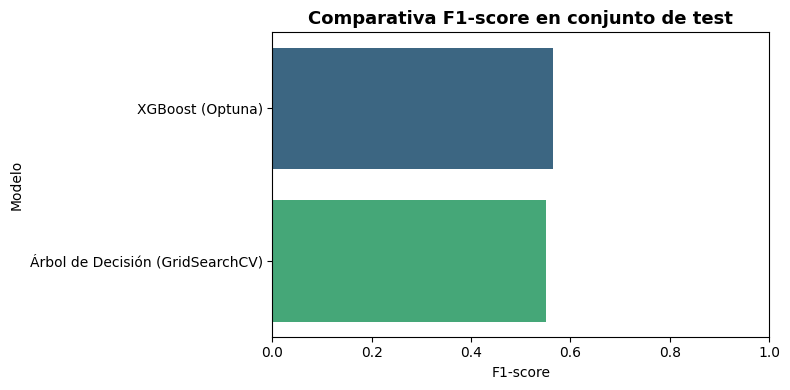

In [8]:
# Consolidar métricas en tabla
metricas_df = pd.DataFrame(resultados_modelos)
metricas_df = metricas_df.sort_values(by=['Conjunto', 'F1-score'], ascending=[True, False])

print("Métricas completas por conjunto:\n")
display(metricas_df)

resumen_test = metricas_df[metricas_df['Conjunto'] == 'Test'].sort_values(by='F1-score', ascending=False)
print("\nRanking en test (ordenado por F1-score):\n")
display(resumen_test)

plt.figure(figsize=(8, 4))
sns.barplot(data=resumen_test, x='F1-score', y='Modelo', palette='viridis')
plt.title('Comparativa F1-score en conjunto de test', fontsize=13, fontweight='bold')
plt.xlim(0, 1)
plt.xlabel('F1-score')
plt.ylabel('Modelo')
plt.tight_layout()
plt.show()

## 5. Interpretabilidad de los Modelos

In [9]:
def plot_feature_importances(importances, titulo, top_n=15):
    """Visualiza las importancias promedio del modelo."""
    fi_df = (
        pd.DataFrame({'feature': feature_names, 'importance': importances})
        .sort_values('importance', ascending=False)
        .head(top_n)
        .iloc[::-1]
    )
    plt.figure(figsize=(8, 6))
    plt.barh(fi_df['feature'], fi_df['importance'], color='steelblue')
    plt.title(titulo, fontsize=13, fontweight='bold')
    plt.xlabel('Importancia')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

### 5.1. XGBoost: Feature Importances y SHAP

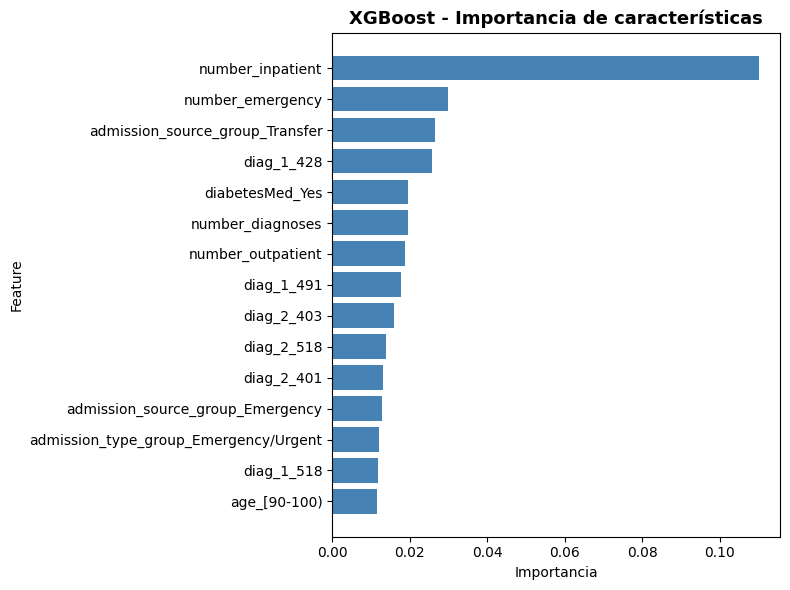

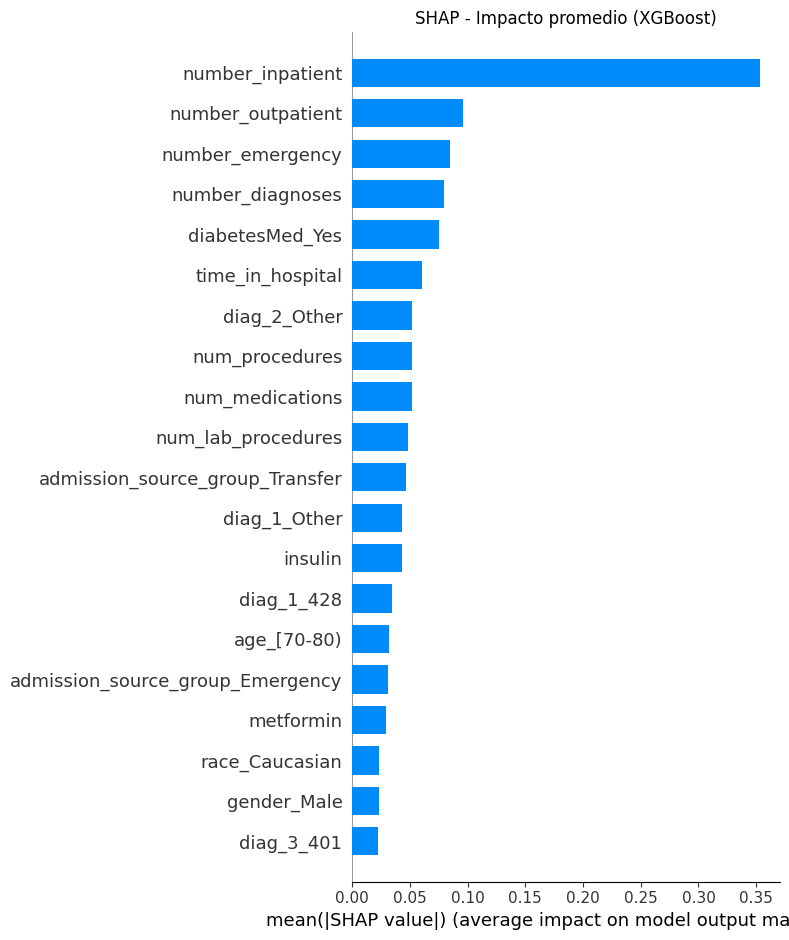

In [10]:
xgb_best = modelos_tunados['XGBoost']
xgb_clf, X_val_xgb = _descomponer_modelo(xgb_best, X_val_array)

plot_feature_importances(xgb_clf.feature_importances_, 'XGBoost - Importancia de características')

sample_size = min(200, X_val_xgb.shape[0])
sample_idx = np.random.choice(X_val_xgb.shape[0], size=sample_size, replace=False)
sample_proc = X_val_xgb[sample_idx]
explainer = shap.TreeExplainer(xgb_clf)
shap_values = explainer.shap_values(sample_proc)
if isinstance(shap_values, list):
    shap_to_plot = shap_values[1]
else:
    shap_to_plot = shap_values
shap.summary_plot(shap_to_plot, sample_proc, feature_names=feature_names, plot_type='bar', show=False)
plt.title('SHAP - Impacto promedio (XGBoost)')
plt.tight_layout()
plt.show()

### 5.3. Árbol de Decisión: Feature Importances y Permutation Importance

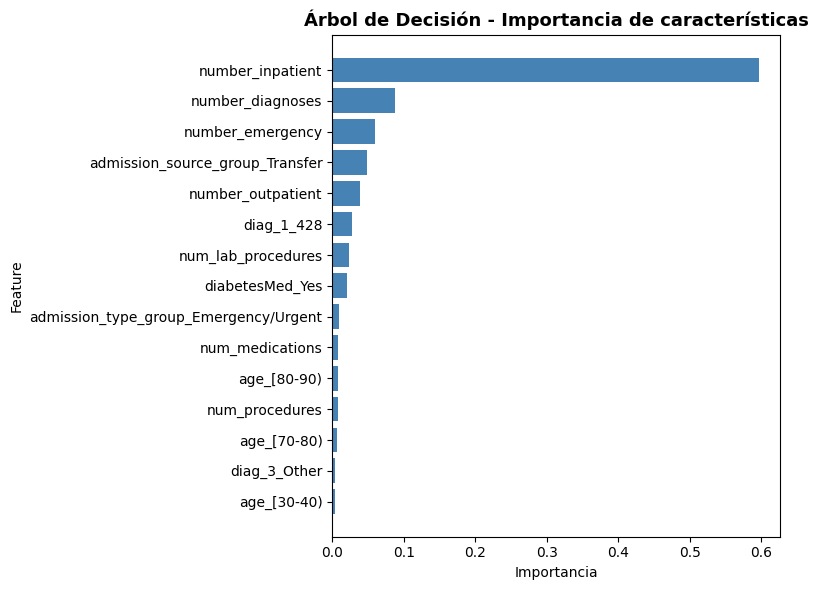

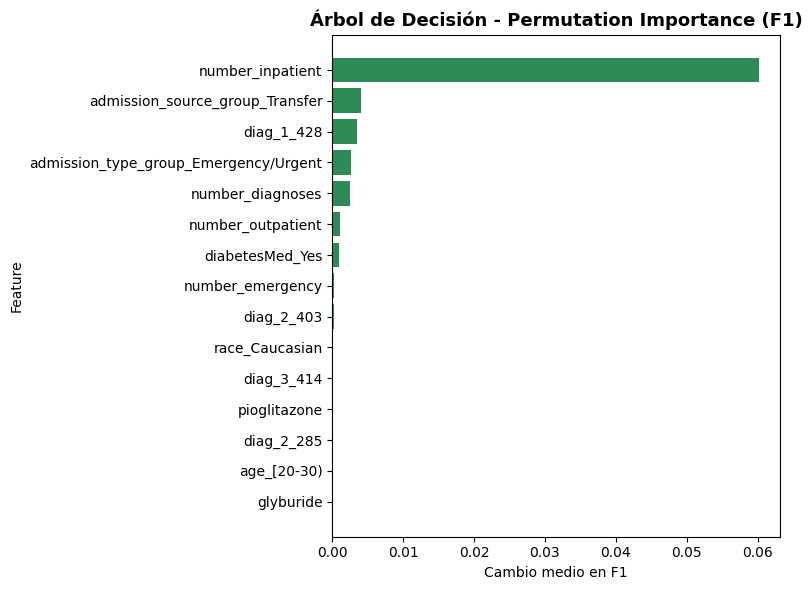

In [12]:
dt_best = modelos_tunados['Árbol de Decisión']
dt_clf, X_val_dt = _descomponer_modelo(dt_best, X_val_array)

plot_feature_importances(dt_clf.feature_importances_, 'Árbol de Decisión - Importancia de características')

perm_dt = permutation_importance(
    dt_clf, X_val_dt, y_val,
    n_repeats=20,
    random_state=42,
    n_jobs=-1,
    scoring='f1'
 )
perm_dt_df = (
    pd.DataFrame({'feature': feature_names, 'importance': perm_dt.importances_mean})
    .sort_values('importance', ascending=False)
    .head(15)
    .iloc[::-1]
)
plt.figure(figsize=(8, 6))
plt.barh(perm_dt_df['feature'], perm_dt_df['importance'], color='seagreen')
plt.title('Árbol de Decisión - Permutation Importance (F1)', fontsize=13, fontweight='bold')
plt.xlabel('Cambio medio en F1')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()